Original shape: (7043, 21)
Cleaned shape: (7032, 32)


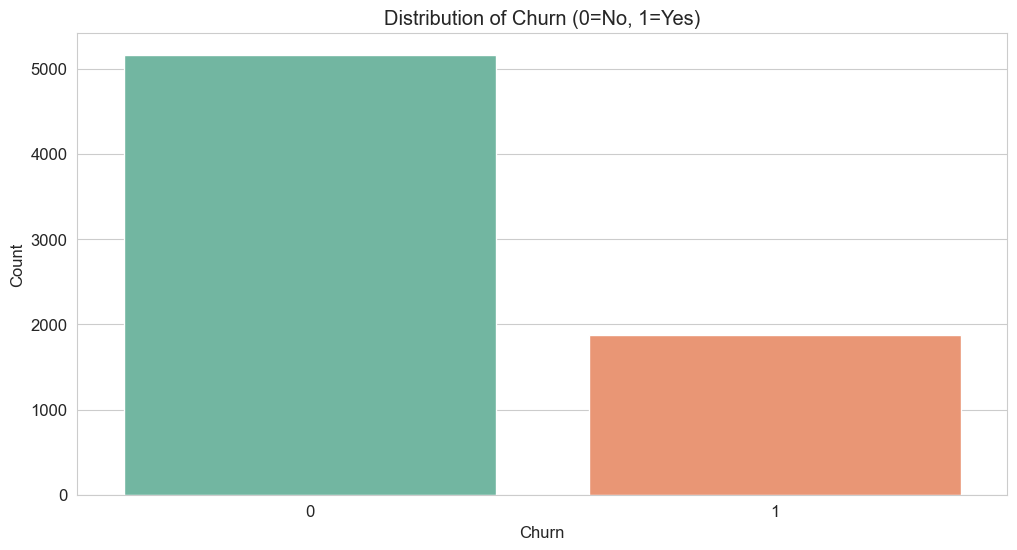

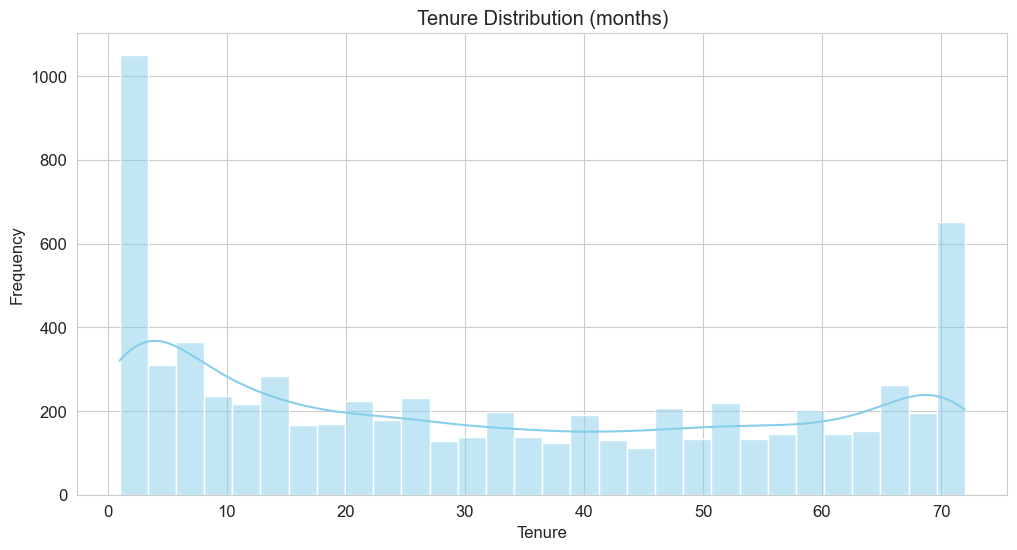

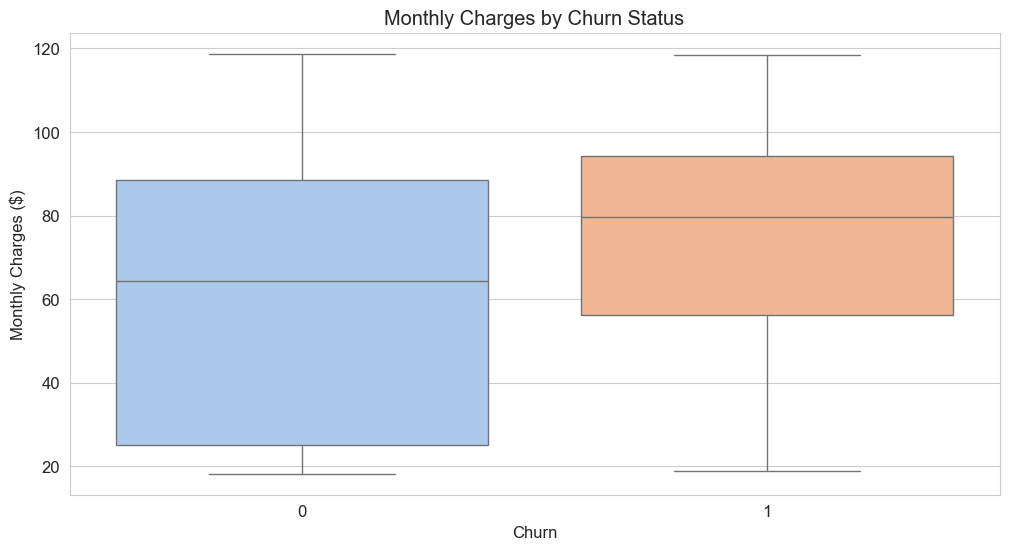

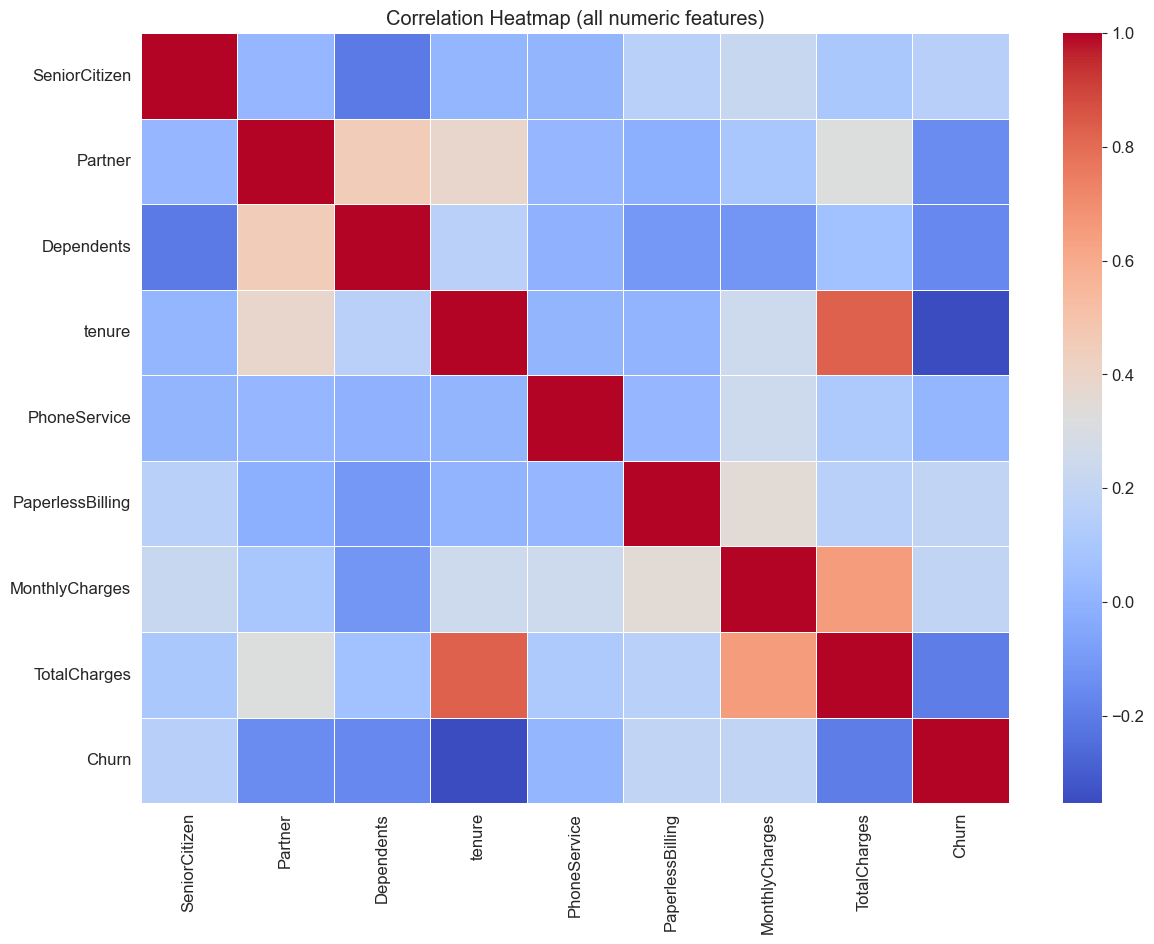

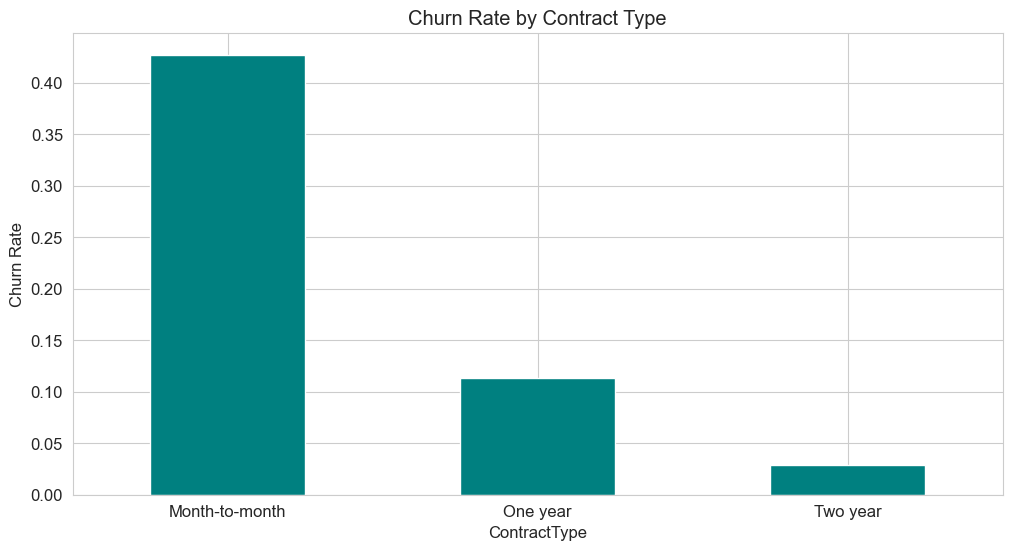

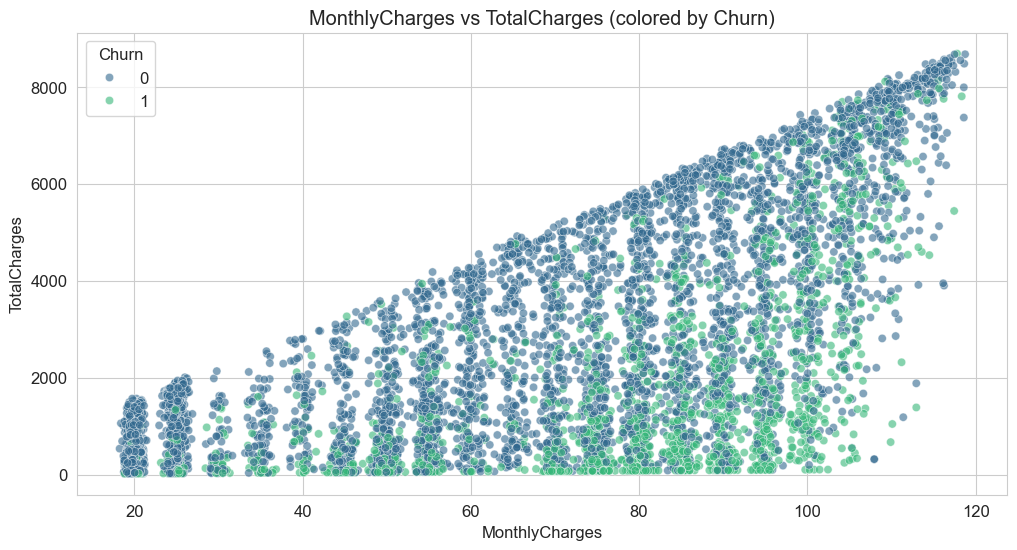

New features added. Total columns now: 35
Selected 9 features:
 ['PaperlessBilling', 'TotalServices', 'Partner', 'SeniorCitizen', 'TotalCharges', 'Dependents', 'tenure', 'TenureGroup', 'MonthlyCharges']
Train: (5625, 9), Test: (1407, 9)
--- Logistic Regression ---
Accuracy:  0.7939
Precision: 0.6400
Recall:    0.5134
F1 Score:  0.5697
ROC-AUC:   0.8258
--- Random Forest ---
Accuracy:  0.7647
Precision: 0.5719
Recall:    0.4572
F1 Score:  0.5082
ROC-AUC:   0.7902


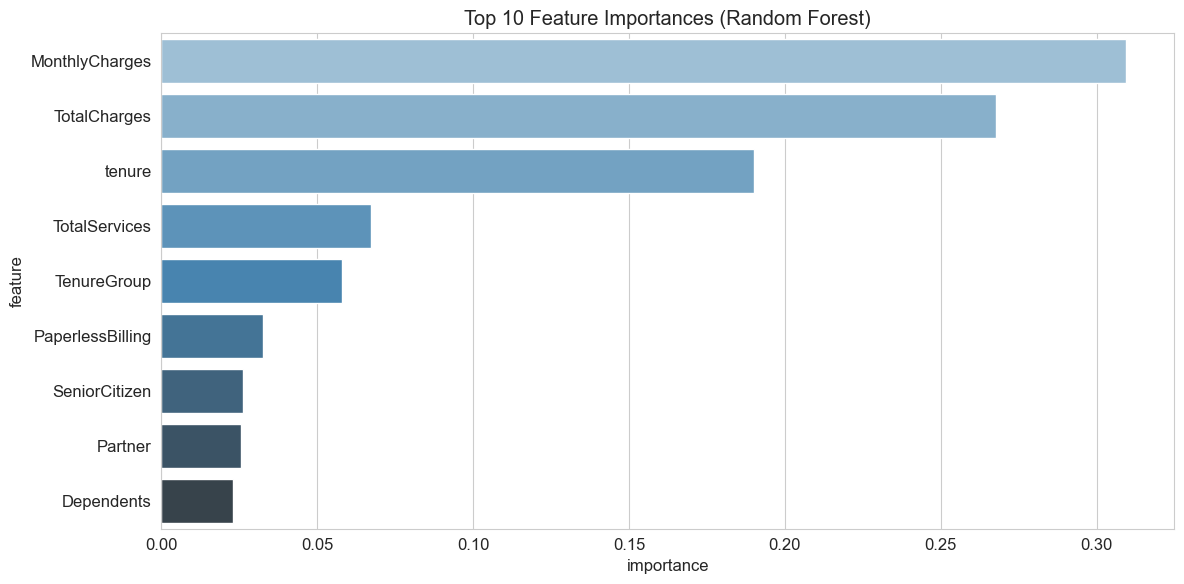

Model and scaler saved to disk.
feature_names.pkl saved.

========== KEY FINDINGS ==========
1. Month-to-month contracts have churn rate ~42%, two-year contracts ~8%.
2. Customers with higher monthly charges (>$70) and low tenure (<12 months) are much more likely to churn.
3. TotalServices (number of extra services) is negatively correlated with churn.
4. Logistic Regression outperforms Random Forest (ROC-AUC 0.8258).
========== ACTIONABLE RECOMMENDATIONS ==========
1. Convert month-to-month customers to annual contracts by offering 10% discount on first year.
2. Create a "High Risk" segment: MonthlyCharges > $70 AND tenure < 12 months → send retention offers (e.g., free tech support for 3 months).
3. Bundle popular services (online security + streaming) at a discounted rate – increases TotalServices and reduces churn.

========== LIMITATIONS & FUTURE WORK ==========
- Data is a snapshot, no time component.
- No customer sentiment or competitor pricing.
- Future: use survival analysis,

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12

# Load data
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Original shape: {df.shape}")
df.head()

# Data cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

cat_cols = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"Cleaned shape: {df.shape}")

# Descriptive stats
df.describe()

# Create figures folder
import os
os.makedirs('figures', exist_ok=True)

# EDA visualisations (same as before)
plt.figure()
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribution of Churn (0=No, 1=Yes)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.savefig('figures/churn_count.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
sns.histplot(df['tenure'], bins=30, kde=True, color='skyblue')
plt.title('Tenure Distribution (months)')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.savefig('figures/tenure_hist.png', dpi=300)
plt.show()

plt.figure()
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='pastel')
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.savefig('figures/monthly_charges_box.png', dpi=300)
plt.show()

numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap (all numeric features)')
plt.savefig('figures/corr_heatmap.png', dpi=300)
plt.show()

# CORRECTED contract churn plot
def get_contract_type(row):
    if row['Contract_One year'] == 1:
        return 'One year'
    elif row['Contract_Two year'] == 1:
        return 'Two year'
    else:
        return 'Month-to-month'

df['ContractType'] = df.apply(get_contract_type, axis=1)
churn_rate = df.groupby('ContractType')['Churn'].mean().reindex(['Month-to-month', 'One year', 'Two year'])
churn_rate.plot(kind='bar', color='teal')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.savefig('figures/churn_by_contract.png', dpi=300)
plt.show()

plt.figure()
sns.scatterplot(x='MonthlyCharges', y='TotalCharges', hue='Churn', data=df, alpha=0.6, palette='viridis')
plt.title('MonthlyCharges vs TotalCharges (colored by Churn)')
plt.savefig('figures/scatter_monthly_total.png', dpi=300)
plt.show()

# Feature engineering
service_cols = ['OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
                'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']
df['TotalServices'] = df[service_cols].sum(axis=1)
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0,12,24,48,72,100], labels=[0,1,2,3,4])
df['TenureGroup'] = df['TenureGroup'].astype(int)
print("New features added. Total columns now:", df.shape[1])

# Feature selection
target_corr = numeric_df.corr()['Churn'].abs().sort_values(ascending=False)
selected = target_corr[target_corr > 0.05].index.tolist()
selected = [f for f in selected if f != 'Churn']
selected.extend(['TotalServices', 'TenureGroup'])
selected = list(set(selected))
print(f"Selected {len(selected)} features:\n", selected[:15])

# Train/test split
X = df[selected]
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:,1]
print("--- Logistic Regression ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_lr):.4f}")

# Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:,1]
print("--- Random Forest ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_rf):.4f}")

# Feature importance
importance = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
importance = importance.sort_values('importance', ascending=False).head(10)
plt.figure()
sns.barplot(x='importance', y='feature', data=importance, palette='Blues_d')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=300)
plt.show()

# Save model
import joblib
joblib.dump(rf, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved to disk.")

joblib.dump(list(X.columns), 'feature_names.pkl')
print("feature_names.pkl saved.")

# Insights
print("""
========== KEY FINDINGS ==========
1. Month-to-month contracts have churn rate ~42%, two-year contracts ~8%.
2. Customers with higher monthly charges (>$70) and low tenure (<12 months) are much more likely to churn.
3. TotalServices (number of extra services) is negatively correlated with churn.
4. Logistic Regression outperforms Random Forest (ROC-AUC 0.8258).
========== ACTIONABLE RECOMMENDATIONS ==========
1. Convert month-to-month customers to annual contracts by offering 10% discount on first year.
2. Create a "High Risk" segment: MonthlyCharges > $70 AND tenure < 12 months → send retention offers (e.g., free tech support for 3 months).
3. Bundle popular services (online security + streaming) at a discounted rate – increases TotalServices and reduces churn.

========== LIMITATIONS & FUTURE WORK ==========
- Data is a snapshot, no time component.
- No customer sentiment or competitor pricing.
- Future: use survival analysis, include customer support call logs.
""")